In [1]:
from limited_data_experiment import do_experiment, ALL_RUNS, EPSGREEDY_EXPECTATION, top_1_normalized_score, top_eps_accuracy
from itertools import count
import multiprocessing as mp
from functools import partial


experiment_setups = []
for seq_id in ALL_RUNS[:1]:
    for gamma in [
        0.25,
        0.5,
        0.75,
        1,
    ]:
        for eps in [
            0,
            0.5,
            0.9,
        ]:
            experiment_setups.append(
                {
                    "incremental_learning": True,
                    "one_decision": False,
                    "seq_id": seq_id,
                    "gamma": gamma,
                    "eps": eps,
                    "batch_size": 128,
                }
            )

    for one_decision in [False, True]:
        experiment_setups.append(
            {
                "incremental_learning": False,
                "one_decision": one_decision,
                "seq_id": seq_id,
                "gamma": 1,
                "eps": 0,
                "batch_size": 128,
            }
        )

cnt = count()
for experiment in experiment_setups:
    experiment["experiment_idx"] = next(cnt)
    experiment["experiments_total"] = len(experiment_setups)

num_processes = mp.cpu_count()
print(f"{num_processes = }")
with mp.Pool(num_processes) as pool:
    results = pool.map(partial(do_experiment, dir="../stats/"), experiment_setups)

# results = [do_experiment(x, dir="../stats/") for x in experiment_setups]

/home/porepy/porepy/src/porepy/numerics/nonlinear/nonlinear_solvers.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange  # type: ignore


num_processes = 16
Start experiment 7 / 14
Start experiment 0 / 14Start experiment 1 / 14

Start experiment 8 / 14
Start experiment 9 / 14Start experiment 2 / 14
Start experiment 6 / 14

Start experiment 11 / 14
Start experiment 12 / 14
Start experiment 10 / 14
Start experiment 3 / 14
Start experiment 5 / 14
Start experiment 13 / 14
Start experiment 4 / 14
Done experiment 13 / 14
Done experiment 12 / 14
Done experiment 10 / 14
Done experiment 9 / 14
Done experiment 11 / 14
Done experiment 6 / 14
Done experiment 8 / 14
Done experiment 7 / 14
Done experiment 4 / 14
Done experiment 1 / 14
Done experiment 0 / 14
Done experiment 3 / 14
Done experiment 5 / 14
Done experiment 2 / 14


[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 15 Terminate: Some process (or the batch system) has told this process to end
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0
[unset]: PMIU_write error; fd=-1 buf=:cmd=abort exitcode=59 message=application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0
:
system msg for write_line failure : Bad file descriptor


In [2]:
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib

matplotlib.rcdefaults()

# tex_fonts = {
#     # Use LaTeX to write all text
#     # "text.usetex": True,
#     "font.family": "serif",
#     "axes.labelsize": 10,
#     "font.size": 10,
#     # Make the legend/label fonts a little smaller
#     "legend.fontsize": 9,
#     "xtick.labelsize": 9,
#     "ytick.labelsize": 9,
# }

# sns.set_theme(
#     # context="talk",
#     context="paper",
#     # rc={"figure.figsize": (8, 6)},
#     # palette="colorblind6",
#     style="whitegrid",
#     rc=tex_fonts,
# )

In [3]:
from collections import defaultdict
import numpy as np
import pandas as pd


data_for_pandas = defaultdict(lambda: [])
for result in results:
    data_for_pandas["incremental_learning"].append(result["incremental_learning"])
    data_for_pandas["one_decision"].append(result["one_decision"])
    data_for_pandas["seq_id"].append(result["seq_id"])
    data_for_pandas["gamma"].append(result["gamma"])
    data_for_pandas["eps"].append(result["eps"])
    data_for_pandas["batch_size"].append(result["batch_size"])
    data_for_pandas["NTS"].append((result["NTS"]))
    data_for_pandas["TopEPS"].append((result["TopEPS"]))
    data_for_pandas["mean_NTS"].append(np.mean(result["NTS"]))
    data_for_pandas["mean_TopEPS"].append(np.mean(result["TopEPS"]))
    data_for_pandas['ypred'].append(result['ypred'])
    data_for_pandas['yoracle'].append(result['yoracle'])
    data_for_pandas['yfeedback'].append(result['yfeedback'])
    data_for_pandas['decision_id'].append(result['decision_id'])


df = pd.DataFrame(data_for_pandas)
df.head()


,incremental_learning,one_decision,seq_id,gamma,eps,batch_size,NTS,TopEPS,mean_NTS,mean_TopEPS,ypred,yoracle,yfeedback,decision_id
0,True,False,R30,0.25,0.0,128,"[0.8831503806923058, 0.8831503806923058, 0.883...","[False, False, False, False, False, False, Fal...",0.984448,0.795448,"[-0.216556191854081, -0.2412591366973296, -0.2...","[-0.05337058008724906, -0.05337058008724906, -...","[-0.14676707376344797, -0.14676707376344797, -...","[614, 613, 613, 613, 613, 613, 613, 613, 613, ..."
1,True,False,R30,0.25,0.5,128,"[0.7982882195841294, -1.0, 0.789644243459886, ...","[False, False, False, False, False, False, Fal...",0.955466,0.632915,"[100.0, 100.0, 100.0, 100.0, -0.24125913669732...","[-0.05337058008724906, -0.05337058008724906, -...","[-0.21459637727549144, -100.0, -0.221505403305...","[860, 1044, 466, 87, 613, 130, 769, 613, 613, ..."
2,True,False,R30,0.25,0.9,128,"[0.7782054444397193, -1.0, 0.7786943421555261,...","[False, False, False, False, False, False, Fal...",0.926079,0.727167,"[100.0, 100.0, 100.0, 100.0, 100.0, -0.1957532...","[-0.05392688986753826, -0.05392688986753826, -...","[-0.23114291416315216, -100.0, -0.230752280095...","[860, 1044, 466, 87, 871, 610, 769, 610, 610, ..."
3,True,False,R30,0.50,0.0,128,"[0.9001768914687931, 0.9001768914687933, 0.900...","[False, False, False, False, False, False, Fal...",0.966791,0.724389,"[-0.5460826745134966, -0.5536384056397017, -0....","[-0.27666920113050564, -0.2968988035015817, -0...","[-0.3518099995222216, -0.37203960189329766, -0...","[695, 695, 695, 695, 695, 698, 698, 698, 698, ..."
4,True,False,R30,0.50,0.5,128,"[0.8413651373475042, -1.0, 0.832525857204532, ...","[False, False, False, False, True, False, Fals...",0.888502,0.322233,"[100.0, 100.0, 100.0, 100.0, -0.23004265057754...","[-0.09927300141848484, -0.10946373708946251, -...","[-0.22321121099477242, -100.0, -0.241148522752...","[860, 1044, 466, 87, 685, 130, 769, 689, 689, ..."


In [4]:
df_heatmap = df[(df.incremental_learning) & ~(df.one_decision)
                #  & ~(df.seq_id.isin(['R30', 'R33']))
                 ]
df_heatmap = df_heatmap.groupby(["eps", 'gamma'])["mean_NTS"].agg(["mean", 'std']).unstack()
df_heatmap

mean                                std               
gamma      0.25      0.50      0.75      1.00 0.25 0.50 0.75 1.00
eps                                                              
0.0    0.984448  0.966791  0.960825  0.915316  NaN  NaN  NaN  NaN
0.5    0.955466  0.888502  0.931600  0.964179  NaN  NaN  NaN  NaN
0.9    0.926079  0.954765  0.960535  0.863690  NaN  NaN  NaN  NaN

In [5]:
annot = df_heatmap['mean'].round(2).astype(str) + "±" + df_heatmap['std'].round(2).astype(str)
annot

gamma,0.25,0.50,0.75,1.00
eps,,,,
0.0,0.98±nan,0.97±nan,0.96±nan,0.92±nan
0.5,0.96±nan,0.89±nan,0.93±nan,0.96±nan
0.9,0.93±nan,0.95±nan,0.96±nan,0.86±nan


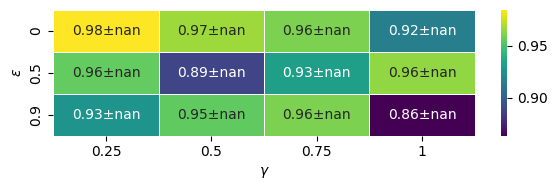

In [6]:
plt.figure(figsize=(6, 2))
sns.heatmap(
    np.array(df_heatmap["mean"]),
    annot=np.array(annot),
    cmap="viridis",
    linecolor="white",
    linewidths=0.5,
    yticklabels=[0, 0.5, 0.9],
    xticklabels=[0.25, 0.5, 0.75, 1],
    fmt="",
)
plt.ylabel(r"$\varepsilon$")
plt.xlabel(r"$\gamma$")
# plt.title(r"Top-$\varepsilon$ Acc.", fontweight="bold")
plt.tight_layout()
# plt.savefig("scenarioA_topeps.pdf")

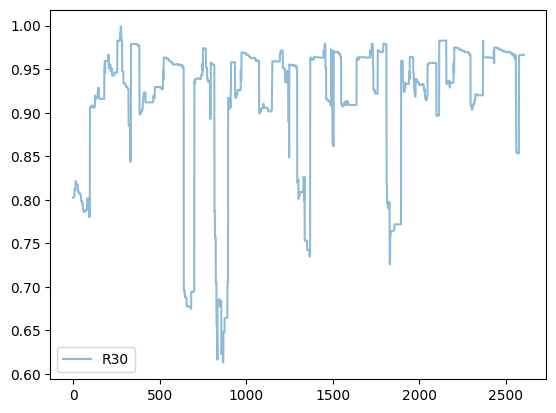

In [7]:
from matplotlib import pyplot as plt

for row in df[(df.eps == 0) & (df.gamma == 1) & (df.incremental_learning) & ~df.one_decision].itertuples(index=False):
    plt.plot((row.NTS), label=row.seq_id, alpha=0.5)
plt.legend()
